# Chapter 91 — Geometry in Programming

> **Prerequisites:** Part III (Functions). Basic Python and numpy.
>
> **Outcomes:** Connect mathematical geometry to programming primitives; Represent geometric objects as data structures; Understand why geometry matters for ML and graphics


## Why Geometry for Programmers

Geometry is the mathematics of **space and shape**. For programmers, it appears in:
- **Computer graphics**: every pixel rendered requires geometric computation
- **Machine learning**: data lives in high-dimensional space; distance, angles, projections are central
- **Game development**: collision detection, physics, pathfinding
- **Robotics**: coordinate transforms, sensor geometry, motion planning
- **GIS and mapping**: distances on spheres, projections, spatial queries

In this Part, we work in 2D. The ideas extend to 3D and beyond.
The key insight: **geometric objects are data structures; geometric operations are functions.**

## Representing Geometry as Data

| Object | Representation |
|--------|---------------|
| Point | (x, y) — a tuple or length-2 array |
| Line segment | (p1, p2) — two points |
| Line (infinite) | (a, b, c) — coefficients of ax + by + c = 0 |
| Circle | (center, radius) — point + scalar |
| Polygon | list of vertices (ordered) |
| Vector | (dx, dy) — displacement, not position |

In code, numpy arrays are the universal container.
A set of N points is an (N, 2) array.
A transformation is a (2, 2) or (3, 3) matrix (ch114).

*(Points introduced in ch092; transformations in ch108–114. This is the data-structure preview.)*

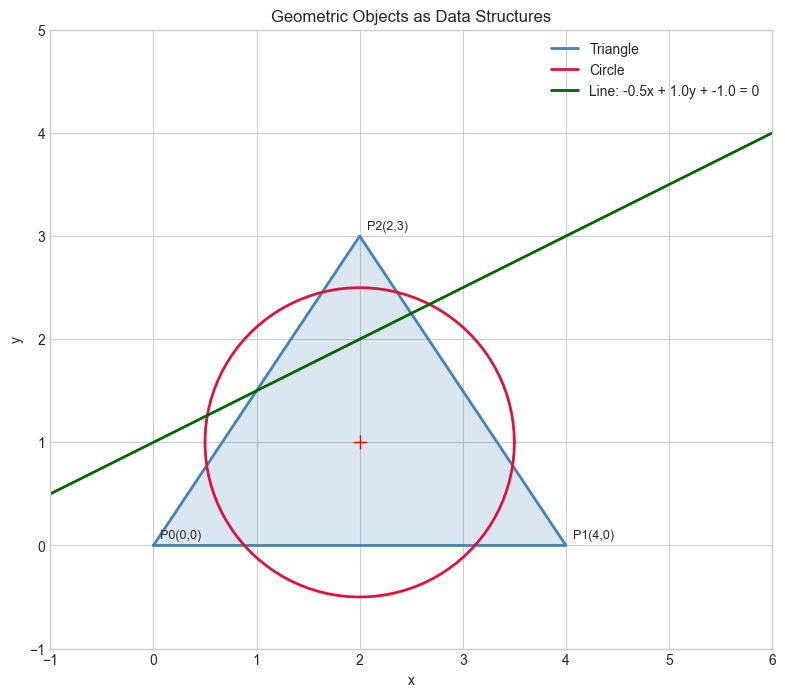

In [1]:
# --- Geometry data structures ---
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

# Represent a triangle as a (3, 2) array
triangle = np.array([[0, 0], [4, 0], [2, 3]], dtype=float)

# Represent a circle as (center, radius)
circle = {'center': np.array([2.0, 1.0]), 'radius': 1.5}

# Represent a line as ax + by + c = 0
# Line y = 0.5x + 1  →  -0.5x + y - 1 = 0  →  (a=-0.5, b=1, c=-1)
line = {'a': -0.5, 'b': 1.0, 'c': -1.0}

# Plot all three
fig, ax = plt.subplots(figsize=(8, 7))

# Triangle
closed = np.vstack([triangle, triangle[0]])
ax.fill(triangle[:,0], triangle[:,1], alpha=0.2, color='steelblue')
ax.plot(closed[:,0], closed[:,1], 'steelblue', linewidth=2, label='Triangle')
for i, (x, y) in enumerate(triangle):
    ax.annotate(f'P{i}({x:.0f},{y:.0f})', (x, y), textcoords='offset points', xytext=(5,5), fontsize=9)

# Circle
theta = np.linspace(0, 2*np.pi, 100)
cx, cy, r = circle['center'][0], circle['center'][1], circle['radius']
ax.plot(cx + r*np.cos(theta), cy + r*np.sin(theta), 'crimson', linewidth=2, label='Circle')
ax.plot(cx, cy, 'r+', markersize=10)

# Line
x_line = np.linspace(-1, 6, 100)
a, b, c = line['a'], line['b'], line['c']
y_line = (-a*x_line - c) / b
ax.plot(x_line, y_line, 'darkgreen', linewidth=2, label=f'Line: {a}x + {b}y + {c} = 0')

ax.set_xlim(-1, 6); ax.set_ylim(-1, 5)
ax.set_aspect('equal'); ax.legend()
ax.set_title('Geometric Objects as Data Structures')
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## Geometry → ML Connection

**Why does geometry appear in ML?**

Every data point in a dataset is a point in high-dimensional space.
- A 28×28 MNIST image is a point in ℝ^784
- Distance between two images = how different they are
- The decision boundary of a classifier = a geometric surface (hyperplane, curve, etc.)

This Part builds the 2D intuition. Part V (Vectors) and Part VI (Linear Algebra) generalize to arbitrary dimensions.

**Forward connections:**
- ch094 (Distance) → generalized to norms in ch128 (Vector Length)
- ch108–114 (Transformations) → matrix operations in ch164–168
- ch103 (Unit Circle) → dot product angles in ch131 (Dot Product)

## Summary

- Geometric objects are data structures: points as arrays, shapes as collections of points
- Geometric operations are functions that transform these data structures
- All transformations in 2D are matrix multiplications (proven in ch114)
- 2D geometry is the foundation for understanding ML's geometric structure

**Next:** ch092 — Points and Coordinate Systems